In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [97]:
path="/content/drive/MyDrive/Data Analysis Portfolio/Super sales Analysis/"
data = pd.read_csv(path + "Superstore sales dataset.csv")
data.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


### Data exploring


In [98]:

print("Data Information :\n ")
print(data.info())



Data Information :
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

In [99]:
print("Number of nulls for column : \n")
print(data.isnull().sum())

Number of nulls for column : 

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [100]:
print("Data statistics : \n")
print(data.describe())

Data statistics : 

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [101]:
#removes all the duplicate rows from the data set.
data.drop_duplicates(inplace = True)

In [102]:
#Feature engineering
data['Ship Date'] = pd.to_datetime(data['Ship Date'],dayfirst = True)

data['Order Date'] = pd.to_datetime(data['Order Date'],dayfirst = True)
data['Month'] = data['Order Date'].dt.month
data['Year'] = data['Order Date'].dt.year
data.tail(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.0,13.320,2,2017
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2,0.0,72.948,5,2017


### Aggregation and Grouping


In [103]:

#Most sold category product.
data['Category'].unique()
print(data.groupby('Category')['Order ID'].count())
print()

#Maximum orders by region.
orders_by_region = data.groupby('Region')['Order ID'].count()
orders_by_region_descending = orders_by_region.sort_values(ascending = False)
print(orders_by_region_descending)

#Maximum delieveries by year.
data.groupby('Year')['Ship Date'].count()

Category
Furniture          2121
Office Supplies    6026
Technology         1847
Name: Order ID, dtype: int64

Region
West       3203
East       2848
Central    2323
South      1620
Name: Order ID, dtype: int64


,Ship Date
Year,
2014,1993
2015,2102
2016,2587
2017,3312


In [104]:
##Pivot Table for orders

display(data.pivot_table(values = 'Order ID', index = 'Category', aggfunc = 'count'))

display(data.pivot_table(values = 'Order ID', index = 'Region' , aggfunc = 'count'))
display(data.pivot_table(values = 'Ship Date', index = 'Year' , aggfunc = 'count'))


display(data.pivot_table(values = 'Ship Date', index = 'Year', columns = 'Category', aggfunc='count'))



,Order ID
Category,
Furniture,2121
Office Supplies,6026
Technology,1847


,Order ID
Region,
Central,2323
East,2848
South,1620
West,3203


,Ship Date
Year,
2014,1993
2015,2102
2016,2587
2017,3312


Category,Furniture,Office Supplies,Technology
Year,,,
2014,421,1217,355
2015,452,1241,409
2016,562,1566,459
2017,686,2002,624


In [105]:
##Pivot Table for sales

display(data.pivot_table(values = 'Sales', index = 'Category', aggfunc = 'sum'))

display(data.pivot_table(values = 'Sales', index = 'Region' , aggfunc = 'sum'))

display(data.pivot_table(values = 'Sales', index = 'Year', columns = 'Category', aggfunc='sum'))

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


Category,Furniture,Office Supplies,Technology
Year,,,
2014,157192.8531,151776.412,175278.233
2015,170518.2370,137233.463,162780.809
2016,198901.4360,183939.982,226364.180
2017,215387.2692,246097.175,271730.811


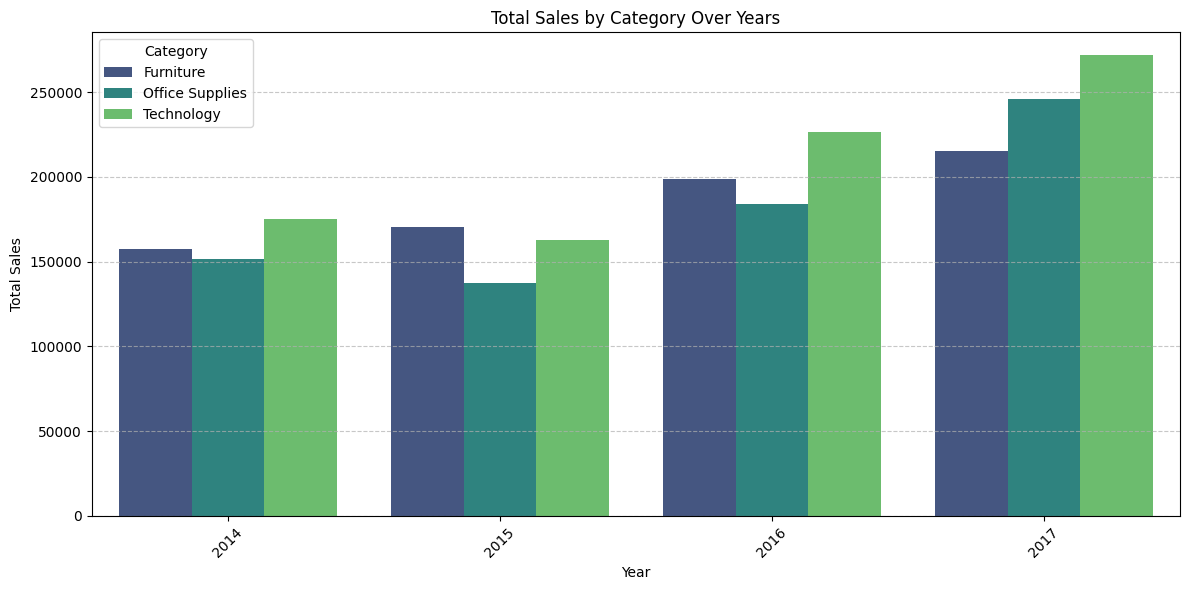

In [106]:


# Calculate total sales per category per year
sales_by_year_category = data.groupby(['Year', 'Category'])['Sales'].sum().reset_index()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Sales', hue='Category', data=sales_by_year_category, palette='viridis')
plt.title('Total Sales by Category Over Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

From the visualization, we can observe the sales trend for each product category over the years.

In [107]:
print("="*50)
print("Analysis")
print("="*50)


print("     - The dataset includes three main product categories: Furniture, Office Supplies, and Technology. \n ")

print("     - The highest-selling category are office supplies, with 6,026 orders. \n ")

print("     - The West region recorded the highest number of customer orders, indicating strong sales activity. \n ")

print("     - From the year 2014 till 2017, maximum number of order totaling 3,312 was achieved. \n ")

print("     - Pivot table analysis further shows  that even though  Office Supplies  sell the most, Technology product makes the makes sales. \n " )

print("     - In the four years (2014-2017), distribution showed steady  growth in all categories, with Technology product sales leading each year. \n ")

Analysis
     - The dataset includes three main product categories: Furniture, Office Supplies, and Technology. 
 
     - The highest-selling category are office supplies, with 6,026 orders. 
 
     - The West region recorded the highest number of customer orders, indicating strong sales activity. 
 
     - From the year 2014 till 2017, maximum number of order totaling 3,312 was achieved. 
 
     - Pivot table analysis further shows  that even though  Office Supplies  sell the most, Technology product makes the makes sales. 
 
     - In the four years (2014-2017), distribution showed steady  growth in all categories, with Technology product sales leading each year. 
 


### Profit Analysis

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


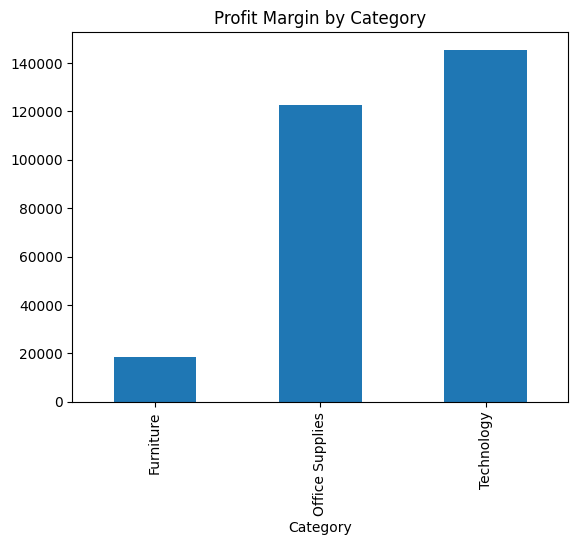

In [108]:
### Profit by Category
profit_category = data.groupby('Category')['Profit'].sum().sort_values()

print(profit_category)

profit_category.plot(kind='bar', title="Profit by Category")
# plt.show()

### Profit Margin
data['Profit Margin'] = data['Profit'] / data['Sales']

margin = data.groupby('Category')['Profit Margin'].mean()

margin.plot(kind='bar', title="Profit Margin by Category")
plt.show()


##regional analysis by profit

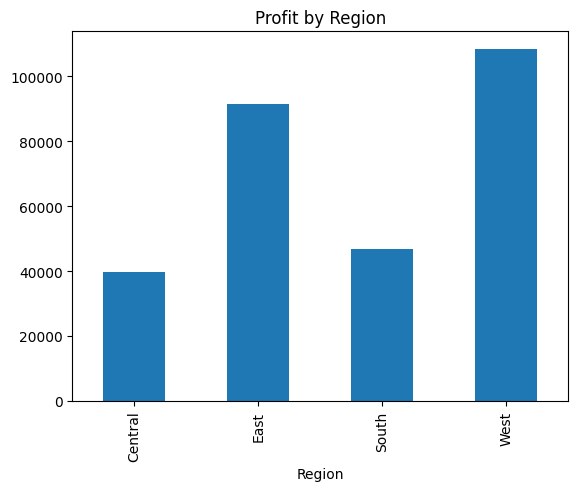

In [109]:
profit_region = data.groupby('Region')['Profit'].sum()

profit_region.plot(kind='bar', title="Profit by Region")
plt.show()


## Loss making products

In [110]:
loss_products = data.groupby('Product Name')['Profit'].sum().sort_values().head(10)

print(loss_products)


Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


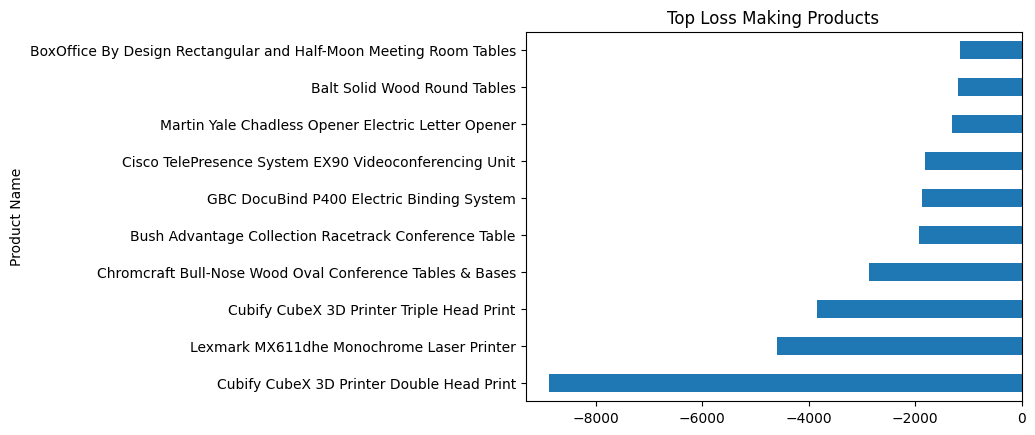


 These are the products that should be discontinued


In [111]:
loss_products.plot(kind='barh', title="Top Loss Making Products")
plt.show()

print("\n These are the products that should be discontinued")


## Customer Analysis

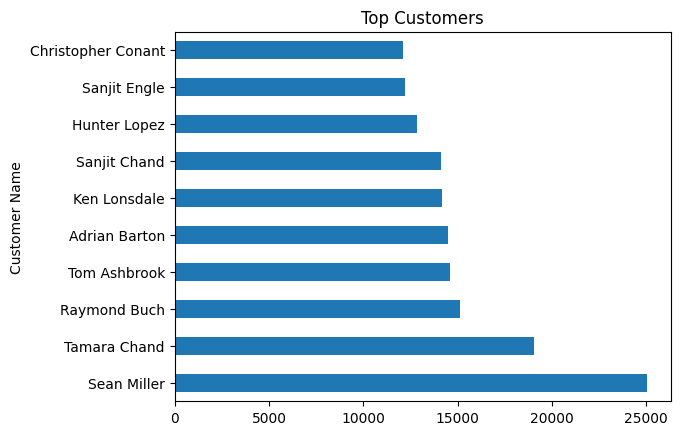

 
 Top customers contribute large revenue, focus on retaining these customers


In [112]:
##Find top customers:
top_customers = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='barh', title="Top Customers")
plt.show()


print(" \n Top customers contribute large revenue, focus on retaining these customers")


#Shipping Analysis

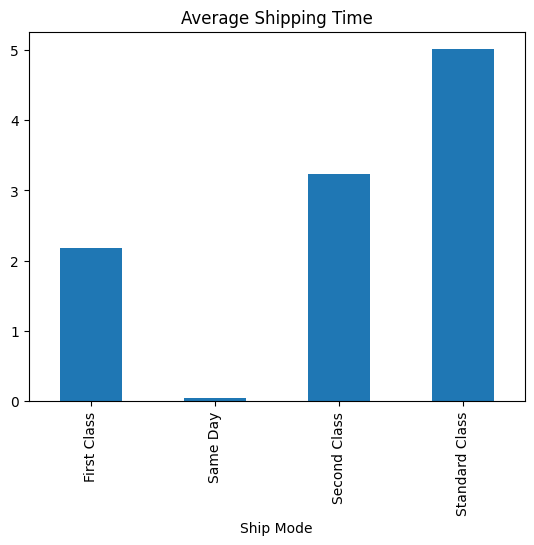

 
 Standard shipping takes longest


In [113]:
#we already have Ship Date.
#Create shipping time:
data['Shipping Time'] = (data['Ship Date'] - data['Order Date']).dt.days

shipping = data.groupby('Ship Mode')['Shipping Time'].mean()

shipping.plot(kind='bar', title="Average Shipping Time")
plt.show()

print(" \n Standard shipping takes longest")


##Correlation Analysis

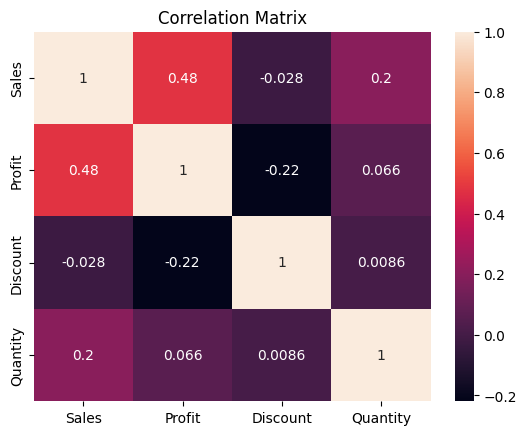

In [114]:
sns.heatmap(data[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


In [115]:
print("="*50)
print("CORRELATION ANALYSIS INSIGHTS")
print("="*50)

print("\n1. Sales and Profit:")
print("There is a positive correlation between Sales and Profit.")
print("This means increasing sales generally increases profit.")

print("\n2. Discount and Profit:")
print("There is a negative correlation between Discount and Profit.")
print("Higher discounts reduce profit.")

print("\n3. Quantity and Profit:")
print("There is weak correlation between Quantity and Profit.")
print("Selling more items does not always increase profit.")

print("\n4. Business Recommendation:")
print("The company should reduce excessive discounts to improve profitability.")


CORRELATION ANALYSIS INSIGHTS

1. Sales and Profit:
There is a positive correlation between Sales and Profit.
This means increasing sales generally increases profit.

2. Discount and Profit:
There is a negative correlation between Discount and Profit.
Higher discounts reduce profit.

3. Quantity and Profit:
There is weak correlation between Quantity and Profit.
Selling more items does not always increase profit.

4. Business Recommendation:
The company should reduce excessive discounts to improve profitability.


In [116]:
corr_matrix = data[['Sales','Profit','Discount','Quantity']].corr()

print(corr_matrix.unstack().sort_values())


Profit    Discount   -0.219487
Discount  Profit     -0.219487
          Sales      -0.028190
Sales     Discount   -0.028190
Quantity  Discount    0.008623
Discount  Quantity    0.008623
Profit    Quantity    0.066253
Quantity  Profit      0.066253
Sales     Quantity    0.200795
Quantity  Sales       0.200795
Sales     Profit      0.479064
Profit    Sales       0.479064
          Profit      1.000000
Sales     Sales       1.000000
Discount  Discount    1.000000
Quantity  Quantity    1.000000
dtype: float64


## Summary

In [117]:
print("="*60)
print("EXECUTIVE SUMMARY: SUPERSTORE SALES ANALYSIS")
print("="*60)

# Total Sales and Profit
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()

print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

# Best Category by Sales
best_sales_category = data.groupby('Category')['Sales'].sum().idxmax()

# Best Category by Profit
best_profit_category = data.groupby('Category')['Profit'].sum().idxmax()

print(f"\nBest Performing Category (Sales): {best_sales_category}")
print(f"Most Profitable Category: {best_profit_category}")

# Worst Category by Profit
worst_profit_category = data.groupby('Category')['Profit'].sum().idxmin()

print(f"Least Profitable Category: {worst_profit_category}")

# Best Region
best_region = data.groupby('Region')['Profit'].sum().idxmax()

print(f"\nMost Profitable Region: {best_region}")

# Loss-making products
loss_count = (data.groupby('Product Name')['Profit'].sum() < 0).sum()

print(f"\nNumber of Loss-Making Products: {loss_count}")

# Shipping Insight
avg_shipping = data['Shipping Time'].mean()

print(f"\nAverage Shipping Time: {avg_shipping:.1f} days")

print("\nKEY INSIGHTS:")

print("- Technology generates highest profit.")
print("- Furniture has low profit despite good sales.")
print("- West region performs best overall.")
print("- Some products cause significant losses.")
print("- Discounts may reduce profitability.")

print("\nBUSINESS RECOMMENDATIONS:")

print("1. Focus on Technology category to increase profit.")
print("2. Review or discontinue loss-making products.")
print("3. Improve performance in low-profit regions.")
print("4. Optimize discount strategy.")
print("5. Improve shipping efficiency.")

print("\nCONCLUSION:")

print("The company is profitable overall, but profit can be increased")
print("by focusing on high-performing categories and reducing losses.")

print("="*60)


EXECUTIVE SUMMARY: SUPERSTORE SALES ANALYSIS

Total Sales: $2,297,200.86
Total Profit: $286,397.02

Best Performing Category (Sales): Technology
Most Profitable Category: Technology
Least Profitable Category: Furniture

Most Profitable Region: West

Number of Loss-Making Products: 301

Average Shipping Time: 4.0 days

KEY INSIGHTS:
- Technology generates highest profit.
- Furniture has low profit despite good sales.
- West region performs best overall.
- Some products cause significant losses.
- Discounts may reduce profitability.

BUSINESS RECOMMENDATIONS:
1. Focus on Technology category to increase profit.
2. Review or discontinue loss-making products.
3. Improve performance in low-profit regions.
4. Optimize discount strategy.
5. Improve shipping efficiency.

CONCLUSION:
The company is profitable overall, but profit can be increased
by focusing on high-performing categories and reducing losses.
